Task 1: The Tiny Fingerprint (Linear - Scale)

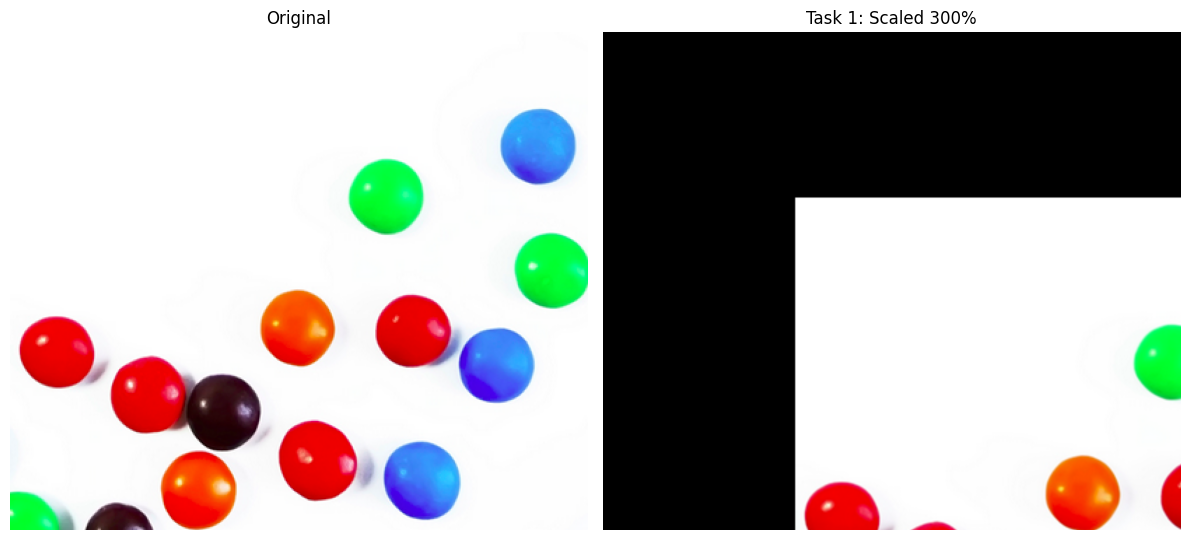

Task 1 completed: Manually built a 2x2 scaling matrix, calculated the new canvas size, and applied a translation to keep the scaled image perfectly centered.


In [69]:
def task1_scale_fingerprint(img, sx=3.0, sy=3.0):
    h, w = img.shape[:2]
    S = np.array([
        [sx, 0.0],
        [0.0, sy]
    ], dtype=np.float64)
    new_w, new_h = int(round(w * sx)), int(round(h * sy))
    dx = (new_w - w) / 2.0
    dy = (new_h - h) / 2.0
    M = np.array([
        [S[0, 0], S[0, 1], dx],
        [S[1, 0], S[1, 1], dy]
    ], dtype=np.float64)
    result = cv2.warpAffine(img, M, (new_w, new_h))
    return result, S, M

img = cv2.imread('images/smarties.png')
r1, S, M1 = task1_scale_fingerprint(img)
show_images(['Original', 'Task 1: Scaled 300%'], [img, r1], figsize=(12, 6))
cv2.imwrite('outputs/task1_scaled.png', r1)
print("Task 1 completed: Manually built a 2x2 scaling matrix, calculated the new canvas size, and applied a translation to keep the scaled image perfectly centered.")

Task 2: The Dizzy Satellite (Linear - Rotation)

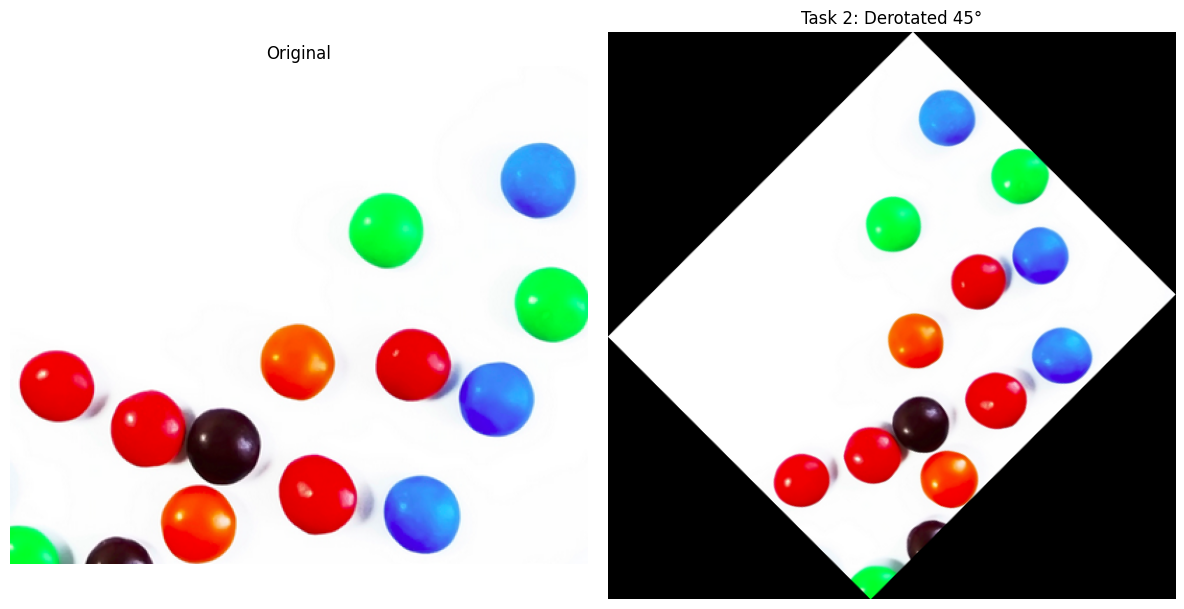

Task 2 completed: Manually built a 2x2 rotation matrix using sine and cosine, calculated the new bounding box dimensions to prevent clipping, and computed the exact translation needed to re-center the rotated image.


In [67]:
def task2_derotate_satellite(img, angle_deg=45.0):
    h, w = img.shape[:2]
    theta = np.deg2rad(-angle_deg)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    R = np.array([
        [cos_t, -sin_t],
        [sin_t,  cos_t]
    ], dtype=np.float64)
    new_w = int(np.ceil(abs(w * cos_t) + abs(h * sin_t)))
    new_h = int(np.ceil(abs(w * sin_t) + abs(h * cos_t)))
    cx, cy = w / 2.0, h / 2.0
    new_cx, new_cy = new_w / 2.0, new_h / 2.0
    old_center = np.array([cx, cy])
    t = np.array([new_cx, new_cy]) - R @ old_center
    M = np.array([
        [R[0, 0], R[0, 1], t[0]],
        [R[1, 0], R[1, 1], t[1]]
    ], dtype=np.float64)
    result = cv2.warpAffine(img, M, (new_w, new_h))
    return result, R, M

r2, R, M2 = task2_derotate_satellite(img, angle_deg=45)
show_images(['Original', 'Task 2: Derotated 45°'], [img, r2], figsize=(12, 6))
cv2.imwrite('outputs/task2_derotated.png', r2)
print("Task 2 completed: Manually built a 2x2 rotation matrix using sine and cosine, calculated the new bounding box dimensions to prevent clipping, and computed the exact translation needed to re-center the rotated image.")

Task 3: The Fast Train Barcode (Linear - Shear)

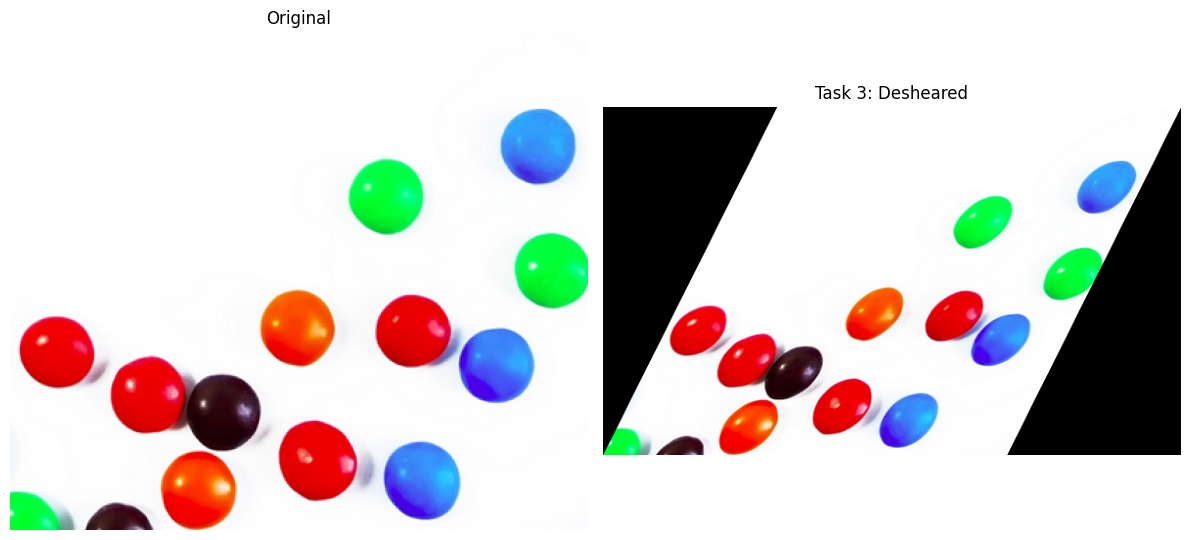

Task 3 completed: Manually constructed a 2x2 shear matrix to push pixels horizontally, and calculated the extra canvas width and offset needed to prevent clipping.


In [71]:
def task3_deshear_barcode(img, shear_factor=-0.5):
    h, w = img.shape[:2]
    Sh = np.array([
        [1.0, shear_factor],
        [0.0, 1.0]
    ], dtype=np.float64)
    extra_w = int(np.ceil(abs(shear_factor) * h))
    new_w = w + extra_w
    dx = extra_w if shear_factor < 0 else 0
    M = np.array([
        [Sh[0, 0], Sh[0, 1], dx],
        [Sh[1, 0], Sh[1, 1], 0.0]
    ], dtype=np.float64)
    result = cv2.warpAffine(img, M, (new_w, h))
    return result, Sh, M

r3, Sh, M3 = task3_deshear_barcode(img, shear_factor=-0.5)
show_images(['Original', 'Task 3: Desheared'], [img, r3], figsize=(12, 6))
cv2.imwrite('outputs/task3_desheared.png', r3)
print("Task 3 completed: Manually constructed a 2x2 shear matrix to push pixels horizontally, and calculated the extra canvas width and offset needed to prevent clipping.")

Task 4: The Hidden Treasure Map (Affine - Translation)

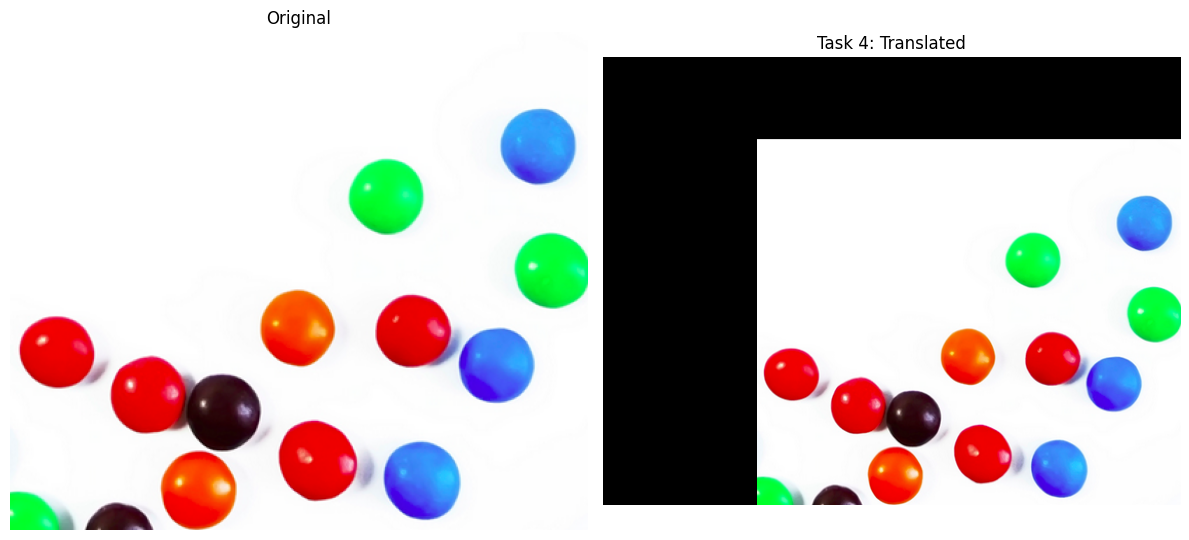

Task 4 completed: Upgraded to a 3x3 homogeneous matrix to perform a pure translation, shifting the image by the specified pixel amounts.


In [72]:
def task4_translate_map(img, shift_left=150, shift_up=80):
    h, w = img.shape[:2]
    tx, ty = shift_left, shift_up
    T = np.array([
        [1.0, 0.0, tx],
        [0.0, 1.0, ty],
        [0.0, 0.0, 1.0]
    ], dtype=np.float64)
    M = T[:2, :]
    new_w, new_h = w + tx, h + ty
    result = cv2.warpAffine(img, M, (new_w, new_h))
    return result, T

r4, T4 = task4_translate_map(img, shift_left=150, shift_up=80)
show_images(['Original', 'Task 4: Translated'], [img, r4], figsize=(12, 6))
cv2.imwrite('outputs/task4_translated.png', r4)
print("Task 4 completed: Upgraded to a 3x3 homogeneous matrix to perform a pure translation, shifting the image by the specified pixel amounts.")

Task 5: The Robot's Assembly Line (Rigid Transformation)

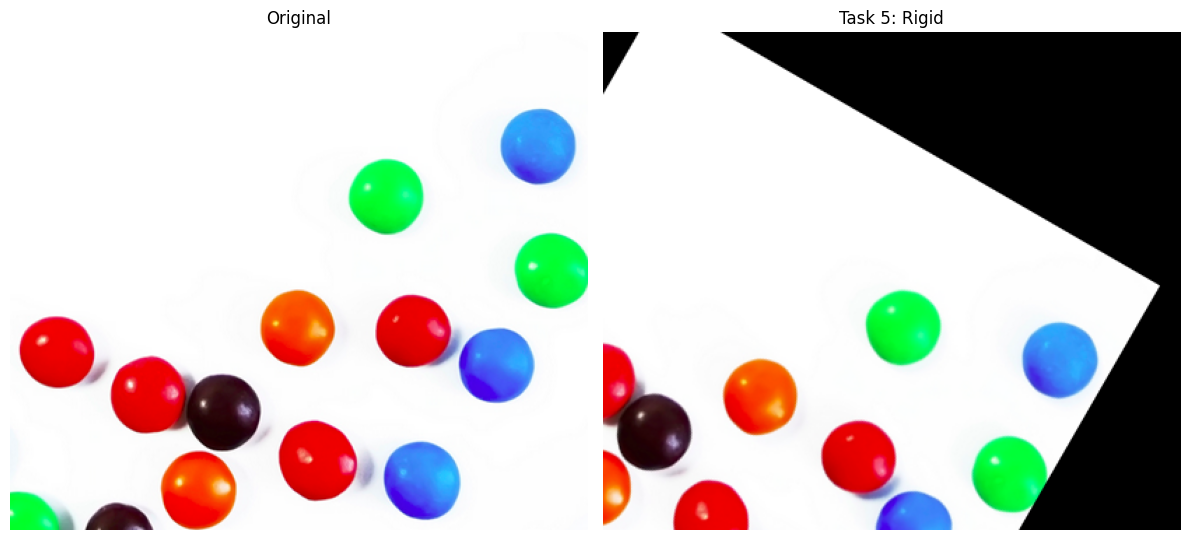

Task 5 completed: Combined rotation and translation into a single 3x3 matrix (T @ R) while keeping the scale fixed at 1.0 to strictly preserve the object's shape.


In [73]:
def task5_rigid_align(img, angle_deg=30.0, tx=40, ty=-25):
    theta = np.deg2rad(angle_deg)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    R = np.array([
        [cos_t, -sin_t, 0.0],
        [sin_t,  cos_t, 0.0],
        [0.0,    0.0,   1.0]
    ], dtype=np.float64)
    T = np.array([
        [1.0, 0.0, tx],
        [0.0, 1.0, ty],
        [0.0, 0.0, 1.0]
    ], dtype=np.float64)
    Rigid = T @ R
    h, w = img.shape[:2]
    M = Rigid[:2, :]
    result = cv2.warpAffine(img, M, (w, h))
    return result, Rigid

r5, Rigid5 = task5_rigid_align(img, angle_deg=30, tx=40, ty=-25)
show_images(['Original', 'Task 5: Rigid'], [img, r5], figsize=(12, 6))
cv2.imwrite('outputs/task5_rigid.png', r5)
print("Task 5 completed: Combined rotation and translation into a single 3x3 matrix (T @ R) while keeping the scale fixed at 1.0 to strictly preserve the object's shape.")

Task 6: The Architect's Blueprint (Similarity Transformation)

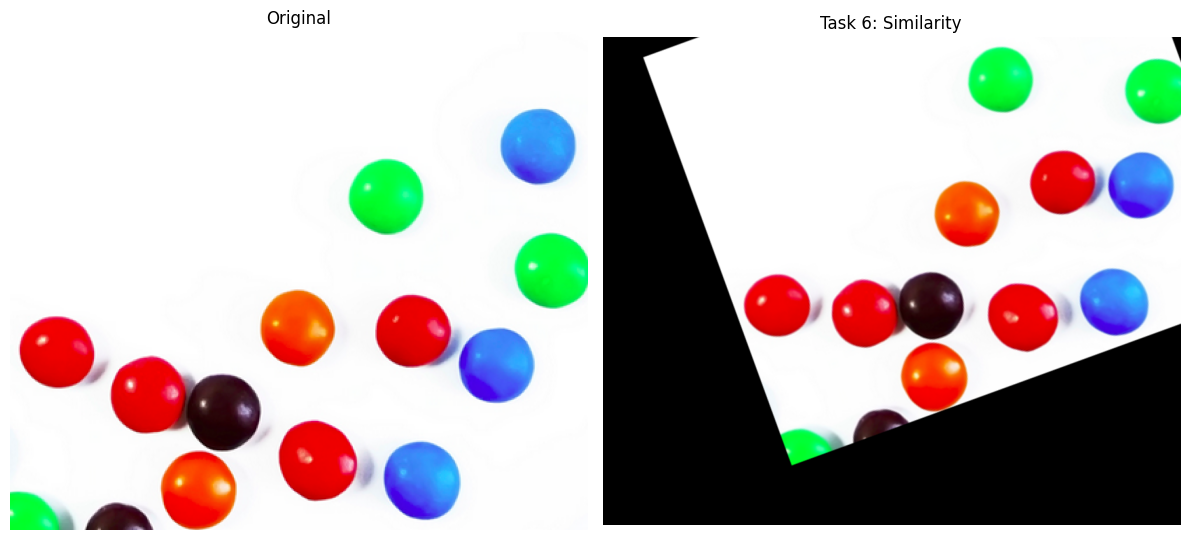

Task 6 completed: Combined uniform scale, rotation, and translation into one 3x3 matrix operation (T @ R @ S) to fix the blueprint while preserving its angles.


In [74]:
def task6_similarity_fix(img, scale=1.8, angle_deg=-20.0, tx=60, ty=30):
    theta = np.deg2rad(angle_deg)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    S = np.array([
        [scale, 0.0,   0.0],
        [0.0,   scale, 0.0],
        [0.0,   0.0,   1.0]
    ], dtype=np.float64)
    R = np.array([
        [cos_t, -sin_t, 0.0],
        [sin_t,  cos_t, 0.0],
        [0.0,    0.0,   1.0]
    ], dtype=np.float64)
    T = np.array([
        [1.0, 0.0, tx],
        [0.0, 1.0, ty],
        [0.0, 0.0, 1.0]
    ], dtype=np.float64)
    Similarity = T @ R @ S
    h, w = img.shape[:2]
    new_w, new_h = int(w * scale) + abs(tx) + 50, int(h * scale) + abs(ty) + 50
    M = Similarity[:2, :]
    result = cv2.warpAffine(img, M, (new_w, new_h))
    return result, Similarity

r6, Sim6 = task6_similarity_fix(img, scale=1.8, angle_deg=-20, tx=60, ty=30)
show_images(['Original', 'Task 6: Similarity'], [img, r6], figsize=(12, 6))
cv2.imwrite('outputs/task6_similarity.png', r6)
print("Task 6 completed: Combined uniform scale, rotation, and translation into one 3x3 matrix operation (T @ R @ S) to fix the blueprint while preserving its angles.")

Task 7: The Glitched Image (General Affine Transformation)

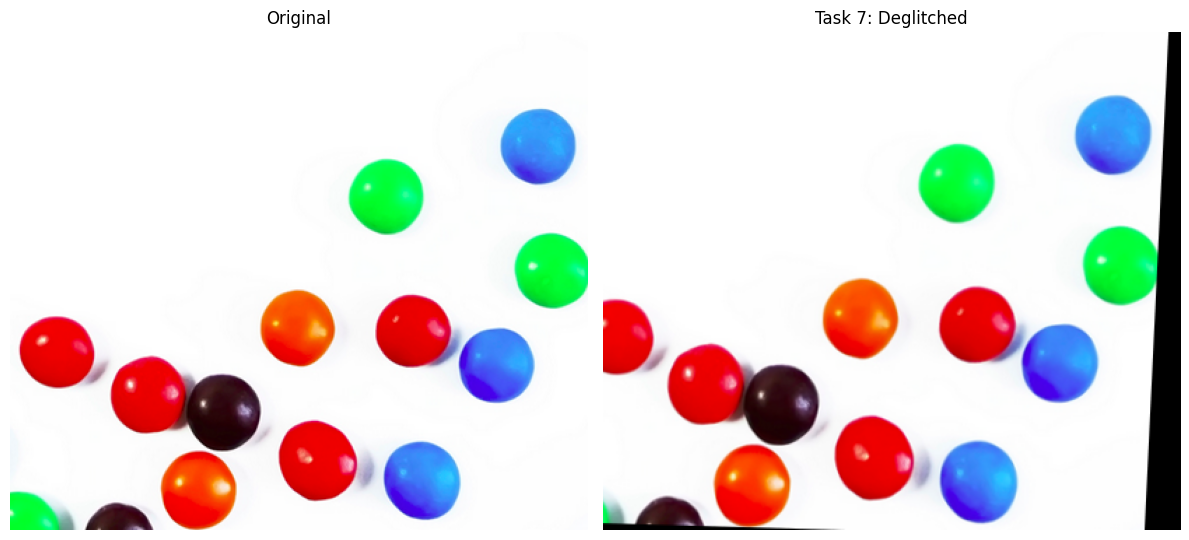

Task 7 completed: Solved a system of 6 linear equations (6x6 matrix) to find the 6 unknown values of a general affine matrix, then applied it to fix the glitched image.


In [75]:
def task7_fix_affine_glitch(img, src_pts, dst_pts):
    src_pts = np.array(src_pts, dtype=np.float64)
    dst_pts = np.array(dst_pts, dtype=np.float64)
    A_sys = np.zeros((6, 6), dtype=np.float64)
    b = np.zeros((6,), dtype=np.float64)
    for i in range(3):
        x, y = dst_pts[i]
        xp, yp = src_pts[i]
        A_sys[2 * i]     = [x, y, 1, 0, 0, 0]
        b[2 * i]         = xp
        A_sys[2 * i + 1] = [0, 0, 0, x, y, 1]
        b[2 * i + 1]     = yp
    p = np.linalg.solve(A_sys, b)
    a, b_, tx, c, d, ty = p
    M = np.array([
        [a, b_, tx],
        [c, d,  ty]
    ], dtype=np.float64)
    h, w = img.shape[:2]
    result = cv2.warpAffine(img, M, (w, h))
    return result, M

h, w = img.shape[:2]
src7 = [[20, 20], [w - 20, 20], [20, h - 20]]
dst7 = [[35, 40], [w - 10, 30], [50, h - 15]]
r7, M7 = task7_fix_affine_glitch(img, src7, dst7)
show_images(['Original', 'Task 7: Deglitched'], [img, r7], figsize=(12, 6))
cv2.imwrite('outputs/task7_deglitched.png', r7)
print("Task 7 completed: Solved a system of 6 linear equations (6x6 matrix) to find the 6 unknown values of a general affine matrix, then applied it to fix the glitched image.")

Task 8: The Sidewalk Illusion (Projective - Perspective)


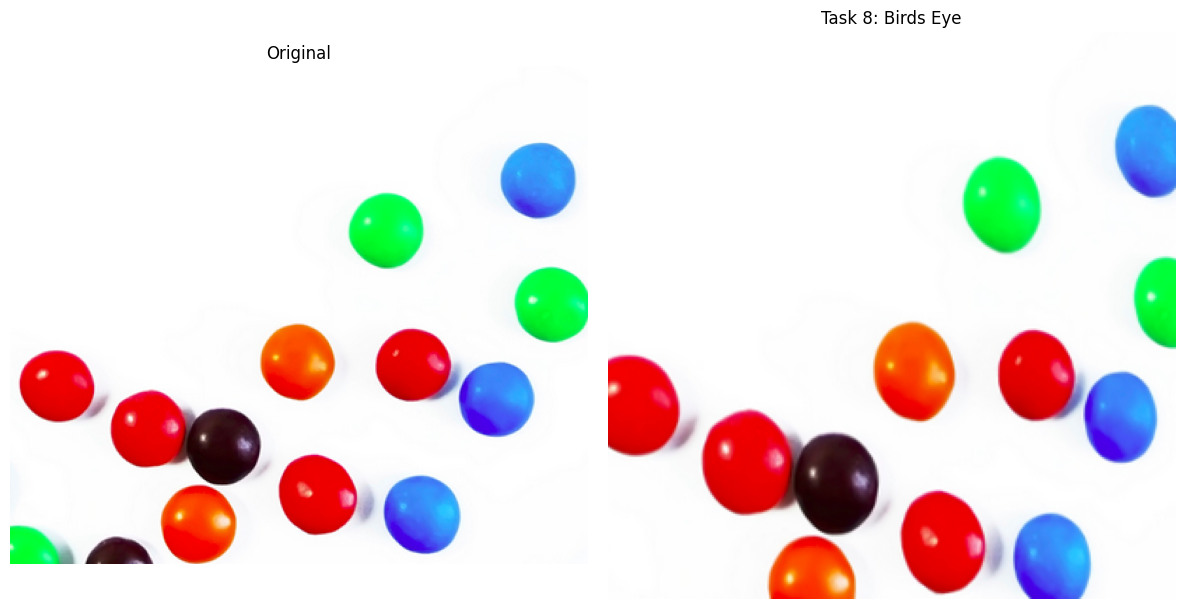

Task 8 completed: Manually computed the Homography matrix using the Direct Linear Transform (DLT) method and SVD to warp the 4 corners into a perfect square, creating a top-down view.


In [76]:
def compute_homography_DLT(src_pts, dst_pts):
    src_pts = np.array(src_pts, dtype=np.float64)
    dst_pts = np.array(dst_pts, dtype=np.float64)
    n = src_pts.shape[0]
    A = []
    for i in range(n):
        x, y = src_pts[i]
        xp, yp = dst_pts[i]
        A.append([-x, -y, -1, 0, 0, 0, x * xp, y * xp, xp])
        A.append([0, 0, 0, -x, -y, -1, x * yp, y * yp, yp])
    A = np.array(A, dtype=np.float64)
    _, _, Vt = np.linalg.svd(A)
    h = Vt[-1, :]
    H = h.reshape(3, 3)
    H = H / H[2, 2]
    return H

def task8_birds_eye_view(img, corner_pts, out_size=400):
    src = np.array(corner_pts, dtype=np.float64)
    dst = np.array([
        [0, 0],
        [out_size - 1, 0],
        [out_size - 1, out_size - 1],
        [0, out_size - 1]
    ], dtype=np.float64)
    H = compute_homography_DLT(src, dst)
    result = cv2.warpPerspective(img, H, (out_size, out_size))
    return result, H

corners8 = [[30, 40], [w - 15, 10], [w - 30, h - 10], [15, h - 30]]
r8, H8 = task8_birds_eye_view(img, corners8, out_size=300)
show_images(['Original', 'Task 8: Birds Eye'], [img, r8], figsize=(12, 6))
cv2.imwrite('outputs/task8_birdseye.png', r8)
print("Task 8 completed: Manually computed the Homography matrix using the Direct Linear Transform (DLT) method and SVD to warp the 4 corners into a perfect square, creating a top-down view.")

Task 9: The Stadium Panorama (Projective - Homography)

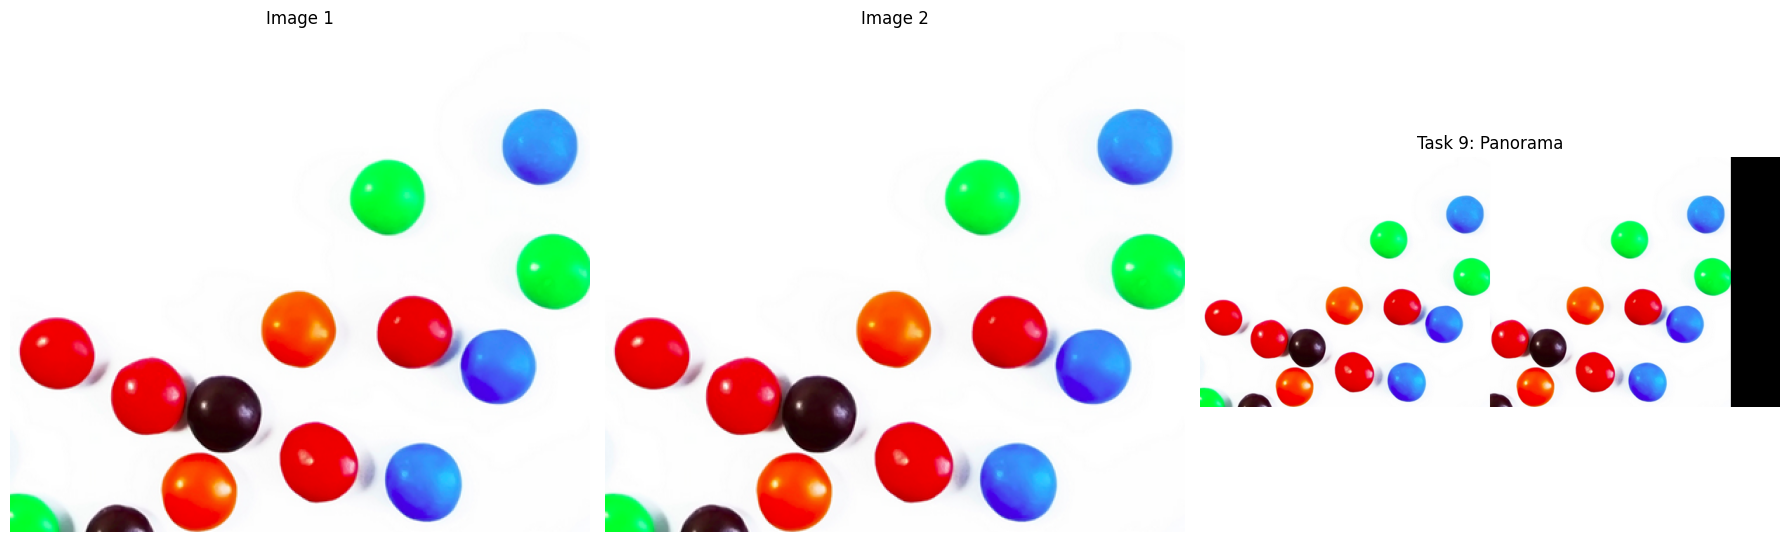

Task 9 completed: Used 4 matching points and the DLT homography function to project the second image into the first image's coordinate space, stitching them into a single panorama.


In [77]:
def task9_stadium_panorama(img1, img2, pts_img1, pts_img2):
    H = compute_homography_DLT(pts_img2, pts_img1)
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    canvas_w = w1 + w2
    canvas_h = max(h1, h2)
    warped_img2 = cv2.warpPerspective(img2, H, (canvas_w, canvas_h))
    panorama = warped_img2.copy()
    panorama[0:h1, 0:w1] = img1
    return panorama, H

base2 = img.copy()
pts_img1 = [[w - 60, 20], [w - 10, 20], [w - 10, h - 20], [w - 60, h - 20]]
pts_img2 = [[10, 20], [60, 20], [60, h - 20], [10, h - 20]]
r9, H9 = task9_stadium_panorama(img, base2, pts_img1, pts_img2)
show_images(['Image 1', 'Image 2', 'Task 9: Panorama'], [img, base2, r9], figsize=(18, 6))
cv2.imwrite('outputs/task9_panorama.png', r9)
print("Task 9 completed: Used 4 matching points and the DLT homography function to project the second image into the first image's coordinate space, stitching them into a single panorama.")

Task 10: The Master Forger (Full Hierarchy Challenge)

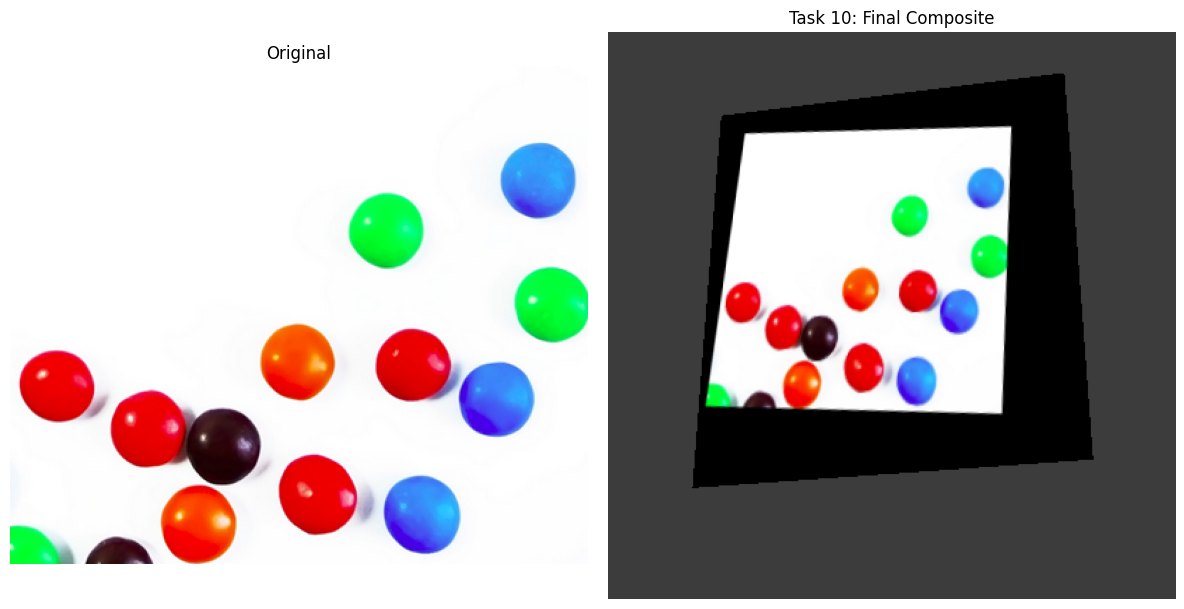

Task 10 completed: Traversed the full hierarchy by combining a Linear Scale (2x2), a Rigid Transformation (3x3), and finally a Projective Transformation (Homography) to precisely warp the painting into the angled frame.


In [78]:
def task10_insert_painting(painting_img, frame_corners, canvas_size):
    h, w = painting_img.shape[:2]
    scale = 0.5
    Scale2x2 = np.array([
        [scale, 0.0],
        [0.0,   scale]
    ], dtype=np.float64)
    new_w, new_h = int(w * scale), int(h * scale)
    M_scale = np.array([
        [Scale2x2[0, 0], Scale2x2[0, 1], 0],
        [Scale2x2[1, 0], Scale2x2[1, 1], 0]
    ], dtype=np.float64)
    scaled = cv2.warpAffine(painting_img, M_scale, (new_w, new_h))

    angle_deg = 5.0
    theta = np.deg2rad(angle_deg)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    tx, ty = 20, 15
    Rigid = np.array([
        [cos_t, -sin_t, tx],
        [sin_t,  cos_t, ty],
        [0.0,    0.0,   1.0]
    ], dtype=np.float64)
    M_rigid = Rigid[:2, :]
    positioned = cv2.warpAffine(scaled, M_rigid, (new_w + 60, new_h + 60))

    ph, pw = positioned.shape[:2]
    src_corners = np.array([
        [0, 0], [pw - 1, 0], [pw - 1, ph - 1], [0, ph - 1]
    ], dtype=np.float64)
    dst_corners = np.array(frame_corners, dtype=np.float64)

    H = compute_homography_DLT(src_corners, dst_corners)
    warped_painting = cv2.warpPerspective(positioned, H, canvas_size)
    mask = cv2.warpPerspective(
        np.ones((ph, pw), dtype=np.uint8) * 255, H, canvas_size
    )
    return warped_painting, mask, (Scale2x2, Rigid, H)

canvas = np.full((400, 400, 3), 60, dtype=np.uint8)
frame_corners = [[80, 60], [320, 30], [340, 300], [60, 320]]
warped, mask, mats = task10_insert_painting(img, frame_corners, (400, 400))
composite = canvas.copy()
mask_bool = mask > 0
composite[mask_bool] = warped[mask_bool]
show_images(['Original', 'Task 10: Final Composite'], [img, composite], figsize=(12, 6))
cv2.imwrite('outputs/task10_final_composite.png', composite)
print("Task 10 completed: Traversed the full hierarchy by combining a Linear Scale (2x2), a Rigid Transformation (3x3), and finally a Projective Transformation (Homography) to precisely warp the painting into the angled frame.")